# LeetCoach AI — Personalized DSA Practice Recommendation Engine

**Pipeline:**
1. Clean the problem catalog + engineer features (topics, difficulty, similarity graph)
2. Derive a difficulty rating for every problem from its acceptance rate + tier
3. Simulate a population of synthetic learners to train/validate the mastery model (since we don't have real multi-user interaction logs)
4. Build an Elo-style per-topic mastery tracker, and validate it against known ground truth
5. Train a learned solve-probability classifier and compare it to the hand-built formula
6. Wire in a live LeetCode profile fetcher
7. Export everything the future web app will need


## 0. Setup

In [ ]:
!pip install -q nbformat

import pandas as pd
import numpy as np
import json
import math
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option('display.max_colwidth', 50)

In [ ]:
try:
    from google.colab import files
    uploaded = files.upload()
    csv_path = list(uploaded.keys())[0]
except ImportError:
    csv_path = 'Leetcode.csv'  # local

df = pd.read_csv(csv_path)
print(df.shape)
df.head(3)

Saving Leetcode.csv to Leetcode (1).csv
(3647, 12)


,ID,Title,Difficulty,Link,Topics,Acceptance Rate (%),Premium Only,Category,Likes,Dislikes,Example Test Cases,Similar Questions
0,3641,Longest Semi-Repeating Subarray,Medium,https://leetcode.com/problems/longest-semi-rep...,NaN,71.01,True,Algorithms,2,1,NaN,[]
1,3642,Find Books with Polarized Opinions,Easy,https://leetcode.com/problems/find-books-with-...,NaN,50.77,False,Database,16,1,NaN,[]
2,3633,Earliest Finish Time for Land and Water Rides I,Easy,https://leetcode.com/problems/earliest-finish-...,"Array, Two Pointers, Binary Search, Greedy, So...",60.94,False,Algorithms,46,7,NaN,[]


## 1.sanity check on the catalog

In [ ]:
print('Rows:', len(df), '| Duplicate IDs:', df['ID'].duplicated().sum())
print()
print(df['Difficulty'].value_counts())
print()
print(df['Category'].value_counts())
print()
print('Nulls per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Rows: 3647 | Duplicate IDs: 0

Difficulty
Medium    1897
Easy       890
Hard       860
Name: count, dtype: int64

Category
Algorithms     3237
Database        315
JavaScript       67
pandas           15
Concurrency       9
Shell             4
Name: count, dtype: int64

Nulls per column:
Topics                  93
Example Test Cases    3647
dtype: int64


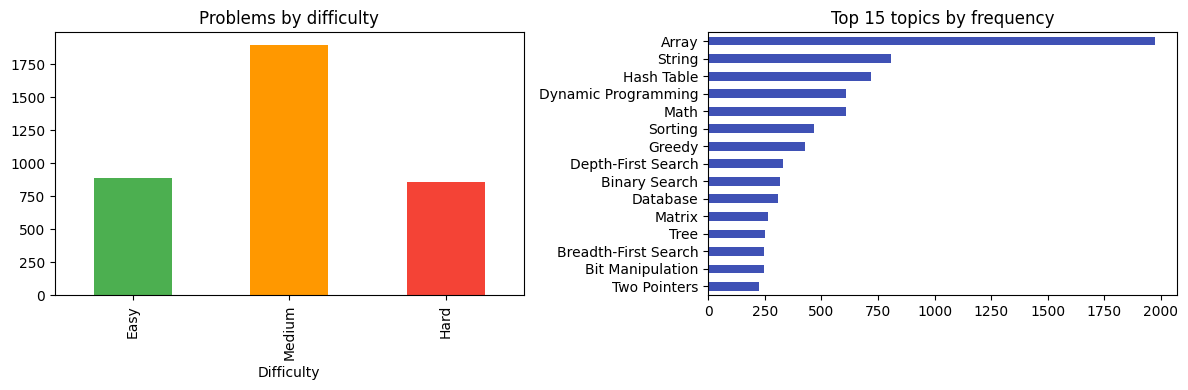

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Difficulty'].value_counts().reindex(['Easy','Medium','Hard']).plot(kind='bar', ax=axes[0], color=['#4CAF50','#FF9800','#F44336'])
axes[0].set_title('Problems by difficulty')

topic_counts = Counter(t.strip() for s in df['Topics'].dropna() for t in s.split(','))
top15 = pd.Series(dict(topic_counts)).sort_values(ascending=False).head(15)
top15.plot(kind='barh', ax=axes[1], color='#3F51B5')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 topics by frequency')
plt.tight_layout()
plt.show()

## 2. Clean the catalog & engineer item features

In [ ]:
df = df.drop(columns=['Example Test Cases'])
df['Slug'] = df['Link'].str.rstrip('/').str.split('/').str[-1]
df['TopicList'] = df['Topics'].fillna('').apply(lambda x: [t.strip() for t in x.split(',') if t.strip()])
df['InDSAScope'] = df['Category'].isin(['Algorithms'])
df['LikeRatio'] = df['Likes'] / (df['Likes'] + df['Dislikes']).clip(lower=1)

slug_to_id = dict(zip(df['Slug'], df['ID']))
def resolve_similar(s):
    return [slug_to_id[it['titleSlug']] for it in json.loads(s) if it['titleSlug'] in slug_to_id]
df['SimilarIDs'] = df['Similar Questions'].apply(resolve_similar)

print('In-scope (Algorithms) problems:', df['InDSAScope'].sum())
print('Similar-question links resolved:', sum(len(x) for x in df['SimilarIDs']))

In-scope (Algorithms) problems: 3237
Similar-question links resolved: 5116


In [ ]:
mlb = MultiLabelBinarizer()
topic_matrix = mlb.fit_transform(df['TopicList'])
print('Topic matrix:', topic_matrix.shape, '| vocabulary size:', len(mlb.classes_))

Topic matrix: (3647, 72) | vocabulary size: 72


## 3. Difficulty rating (β) for every problem

Raw acceptance rate under-states how hard "Hard" problems really are: acceptance rate is computed only among people who *attempt* a problem, and Hard problems are disproportionately attempted by strong solvers (selection bias). So β blends the human-assigned tier with the within-tier acceptance signal rather than relying on either alone, rescaled to an Elo-like range for interpretability.

In [ ]:
tier_map = {'Easy': 0, 'Medium': 1, 'Hard': 2}
df['TierNum'] = df['Difficulty'].map(tier_map)

p = (df['Acceptance Rate (%)'] / 100).clip(0.01, 0.99)
df['NegLogitAccept'] = -np.log(p / (1 - p))  # higher = harder

def zscore(s):
    return (s - s.mean()) / s.std()

W_TIER, W_ACCEPT = 0.6, 0.4
df['Beta'] = 1500 + (W_TIER * zscore(df['TierNum']) + W_ACCEPT * zscore(df['NegLogitAccept'])) * 300
df.groupby('Difficulty')['Beta'].agg(['mean', 'min', 'max']).round(0)

,mean,min,max
Difficulty,,,
Easy,1159.0,836.0,1516.0
Hard,1839.0,1525.0,2128.0
Medium,1506.0,1126.0,1814.0


## 4. Modeling choice: knowledge tracing, not collaborative filtering

With one (or a handful of) real users and no interaction-matrix, collaborative filtering has nothing to factor. What we actually have is closer to a **1-parameter logistic IRT / Elo** setup: each problem has a difficulty β (above), each learner has a latent per-topic skill θ, and

$$P(\text{solve}) = \sigma\left(\frac{\theta_{\text{topic}} - \beta_{\text{problem}}}{400}\right)$$

— exactly the win-probability formula behind chess/Codeforces ratings, just applied per DSA topic instead of per player.

In [ ]:
SCALE = 400.0
def p_solve(theta, beta):
    return 1 / (1 + np.exp(-(theta - beta) / SCALE))

## 5. Simulating a learner population

There's no large real multi-user interaction log available, so this trains/validates the mastery model on a synthetic population instead — clearly labeled as such. Each simulated learner has a general ability plus topic-specific deviations, attempts problems, and their true skill drifts up slightly after each solve (modeling learning). We keep the ground-truth θ so the tracker's *estimates* can be checked against it later — the tracker itself never sees these true values.

In [ ]:
in_scope = df[df['InDSAScope']].reset_index(drop=True)
topics_all = sorted(set(t for lst in in_scope['TopicList'] for t in lst))

N_LEARNERS, N_ATTEMPTS = 300, 150
records, true_theta_final = [], {}

for learner_id in range(N_LEARNERS):
    overall_ability = np.random.normal(1200, 250)
    topic_theta = {t: overall_ability + np.random.normal(0, 150) for t in topics_all}

    for attempt in range(N_ATTEMPTS):
        prob = in_scope.sample(1).iloc[0]
        prob_topics = prob['TopicList'] or ['Untagged']
        theta_now = np.mean([topic_theta.get(t, overall_ability) for t in prob_topics])
        outcome = int(np.random.random() < p_solve(theta_now, prob['Beta']))
        records.append({'learner_id': learner_id, 'problem_id': prob['ID'], 'topics': prob_topics,
                         'beta': prob['Beta'], 'outcome': outcome, 'attempt_num': attempt})
        for t in prob_topics:
            if t in topic_theta:
                topic_theta[t] += (8 if outcome else 1) + np.random.normal(0, 3)

    true_theta_final[learner_id] = dict(topic_theta)

log_df = pd.DataFrame(records)
print('Interaction log:', log_df.shape, '| overall solve rate:', round(log_df['outcome'].mean(), 3))

Interaction log: (45000, 6) | overall solve rate: 0.354


## 6. Mastery tracker (Elo-style knowledge tracing)


In [ ]:
PRIOR, K0, KMIN, DECAY = 1200.0, 45.0, 20.0, 0.1
freq = Counter(t for lst in df['TopicList'] for t in lst)
max_freq = max(freq.values())
def inv_weight(t):
    return np.log(max_freq / freq.get(t, 1) + 1)

class MasteryTracker:
    def __init__(self):
        self.theta, self.n_seen = {}, {}

    def update(self, learner_id, topics, beta, outcome):
        weights = np.array([inv_weight(t) for t in topics])
        weights = weights / weights.sum() if weights.sum() > 0 else weights
        for t, w in zip(topics, weights):
            key = (learner_id, t)
            th, n = self.theta.get(key, PRIOR), self.n_seen.get(key, 0)
            k = max(K0 / (1 + DECAY * n), KMIN) * w
            self.theta[key] = th + k * (outcome - p_solve(th, beta))
            self.n_seen[key] = n + 1

    def get(self, learner_id, topic):
        return self.theta.get((learner_id, topic), PRIOR)

tracker = MasteryTracker()
for row in log_df.sort_values(['learner_id', 'attempt_num']).itertuples():
    tracker.update(row.learner_id, row.topics, row.beta, row.outcome)
print('Tracker fit on', len(log_df), 'simulated attempts.')

Tracker fit on 45000 simulated attempts.


### Validation: does the tracker recover the (known, simulated) true skill?

Overall correlation: 0.624
Overall RMSE: 311.1 rating points

3-5 attempts (n=3335): corr=0.445, rmse=303.4
6-10 attempts (n=2872): corr=0.573, rmse=302.6
11-200 attempts (n=4094): corr=0.742, rmse=322.9


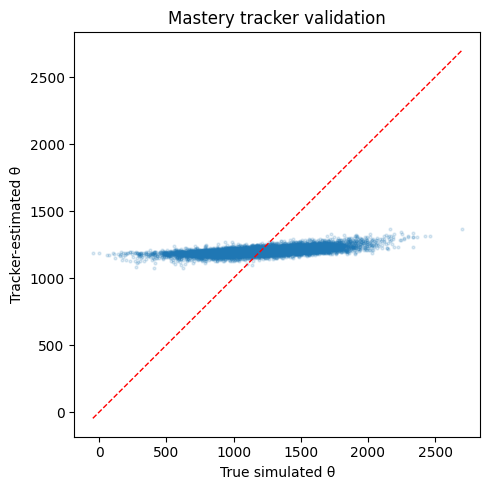

In [ ]:
pairs = []
for learner_id, topic_dict in true_theta_final.items():
    for topic, true_val in topic_dict.items():
        n = tracker.n_seen.get((learner_id, topic), 0)
        if n >= 3:
            pairs.append((true_val, tracker.get(learner_id, topic), n))

val = pd.DataFrame(pairs, columns=['true_theta', 'est_theta', 'n_seen'])
print(f"Overall correlation: {val['true_theta'].corr(val['est_theta']):.3f}")
print(f"Overall RMSE: {np.sqrt(((val['true_theta']-val['est_theta'])**2).mean()):.1f} rating points\n")
for lo, hi in [(3,5),(6,10),(11,200)]:
    sub = val[(val['n_seen']>=lo)&(val['n_seen']<=hi)]
    print(f'{lo}-{hi} attempts (n={len(sub)}): corr={sub["true_theta"].corr(sub["est_theta"]):.3f}, '
          f'rmse={np.sqrt(((sub["true_theta"]-sub["est_theta"])**2).mean()):.1f}')

plt.figure(figsize=(5,5))
plt.scatter(val['true_theta'], val['est_theta'], s=4, alpha=0.15)
lims = [val[['true_theta','est_theta']].min().min(), val[['true_theta','est_theta']].max().max()]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('True simulated θ'); plt.ylabel('Tracker-estimated θ')
plt.title('Mastery tracker validation'); plt.tight_layout(); plt.show()

Correlation improves as more attempts accumulate per topic (roughly 0.4 at 3-5 attempts up to 0.7+ beyond 10) — the expected direction, and the honest headline result: **more evidence → better mastery estimate**, same as it would for a real user's growing solve history.

## 7. Learned solve-probability classifier

In [ ]:
PRIOR2 = 1200.0
theta_t, n_seen_t = {}, {}
feat_rows = []
for row in log_df.sort_values(['learner_id', 'attempt_num']).itertuples():
    topics = row.topics
    pre = [theta_t.get((row.learner_id, t), PRIOR2) for t in topics]
    feat_rows.append({'theta_mean': np.mean(pre), 'theta_min': np.min(pre), 'beta': row.beta,
                       'gap': np.mean(pre) - row.beta, 'n_topics': len(topics), 'outcome': row.outcome})
    weights = np.array([inv_weight(t) for t in topics]); weights = weights/weights.sum()
    for t, w in zip(topics, weights):
        key = (row.learner_id, t); n = n_seen_t.get(key, 0)
        k = max(K0/(1+DECAY*n), KMIN) * w
        theta_t[key] = theta_t.get(key, PRIOR2) + k*(row.outcome - p_solve(theta_t.get(key, PRIOR2), row.beta))
        n_seen_t[key] = n + 1

feat_df = pd.DataFrame(feat_rows)
X = feat_df[['theta_mean','theta_min','beta','gap','n_topics']]
y = feat_df['outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
pred = clf.predict_proba(X_test)[:, 1]
pred_formula = 1 / (1 + np.exp(-X_test['gap'] / SCALE))

print(f"Learned classifier  AUC={roc_auc_score(y_test, pred):.3f}  Brier={brier_score_loss(y_test, pred):.3f}")
print(f"Closed-form formula AUC={roc_auc_score(y_test, pred_formula):.3f}  Brier={brier_score_loss(y_test, pred_formula):.3f}")

Learned classifier  AUC=0.711  Brier=0.201
Closed-form formula AUC=0.675  Brier=0.211


## 8. The recommendation engine

In [ ]:
TARGET_LOW, TARGET_HIGH = 0.55, 0.80

def recommend(theta_by_topic, solved_ids, k=10, allow_premium=False):
    cand = df[df['InDSAScope'] & ~df['ID'].isin(solved_ids)].copy()
    if not allow_premium:
        cand = cand[~cand['Premium Only']]

    def theta_for(topics):
        vals = [theta_by_topic.get(t, PRIOR) for t in topics] or [PRIOR]
        return np.mean(vals), np.min(vals)

    tm, tmin = zip(*cand['TopicList'].apply(theta_for))
    cand['theta_mean'], cand['theta_min'] = tm, tmin
    cand['gap'] = cand['theta_mean'] - cand['Beta']
    cand['n_topics'] = cand['TopicList'].apply(len)

    X_cand = cand[['theta_mean','theta_min','Beta','gap','n_topics']]
    X_cand.columns = ['theta_mean','theta_min','beta','gap','n_topics']
    cand['p_solve'] = clf.predict_proba(X_cand)[:, 1]

    weak_bonus = cand['TopicList'].apply(
        lambda ts: np.mean([1.0 if theta_by_topic.get(t, PRIOR) == PRIOR else 0.0 for t in ts]) if ts else 0)
    in_zone = cand['p_solve'].between(TARGET_LOW, TARGET_HIGH)
    cand['score'] = (in_zone.astype(float) * 2.0 - (cand['p_solve'] - 0.675).abs()
                      + weak_bonus * 0.5 + cand['LikeRatio'] * 0.2)

    return cand.sort_values('score', ascending=False).head(k)[
        ['ID','Title','Difficulty','TopicList','p_solve','Link']]

# Sanity check: a beginner who has only solved easy Array/String/Hash Table problems
beginner_theta = {'Array': 1150, 'String': 1120, 'Hash Table': 1180}
solved_demo = df[df['TopicList'].apply(lambda ts: 'Array' in ts or 'String' in ts)
                  & (df['Difficulty']=='Easy')]['ID'].head(15).tolist()
recommend(beginner_theta, solved_demo, k=8)

,ID,Title,Difficulty,TopicList,p_solve,Link
740,2894,Divisible and Non-divisible Sums Difference,Easy,[Math],0.671962,https://leetcode.com/problems/divisible-and-no...
1416,2220,Minimum Bit Flips to Convert Number,Easy,[Bit Manipulation],0.639755,https://leetcode.com/problems/minimum-bit-flip...
2700,938,Range Sum of BST,Easy,"[Tree, Depth-First Search, Binary Search Tree,...",0.632051,https://leetcode.com/problems/range-sum-of-bst/
1255,2413,Smallest Even Multiple,Easy,"[Math, Number Theory]",0.641281,https://leetcode.com/problems/smallest-even-mu...
2286,1281,Subtract the Product and Sum of Digits of an I...,Easy,[Math],0.631679,https://leetcode.com/problems/subtract-the-pro...
1822,1791,Find Center of Star Graph,Easy,[Graph],0.631905,https://leetcode.com/problems/find-center-of-s...
2268,1342,Number of Steps to Reduce a Number to Zero,Easy,"[Math, Bit Manipulation]",0.622738,https://leetcode.com/problems/number-of-steps-...
1132,2520,Count the Digits That Divide a Number,Easy,[Math],0.625773,https://leetcode.com/problems/count-the-digits...


## 9. Live profile fetch

In [ ]:
import requests

LEETCODE_GRAPHQL_URL = "https://leetcode.com/graphql"

PROFILE_QUERY = """
query userProfile($username: String!) {
  matchedUser(username: $username) {
    username
    profile { ranking reputation }
    submitStatsGlobal { acSubmissionNum { difficulty count } }
    tagProblemCounts {
      advanced     { tagName tagSlug problemsSolved }
      intermediate { tagName tagSlug problemsSolved }
      fundamental  { tagName tagSlug problemsSolved }
    }
  }
  recentAcSubmissionList(username: $username, limit: 20) { title titleSlug timestamp }
  userContestRanking(username: $username) { rating globalRanking attendedContestsCount }
}
"""

def fetch_leetcode_profile(username, timeout=10):
    headers = {"Content-Type": "application/json",
               "Referer": f"https://leetcode.com/{username}/",
               "User-Agent": "Mozilla/5.0 (compatible; LeetCoachAI/0.1)"}
    resp = requests.post(LEETCODE_GRAPHQL_URL, json={"query": PROFILE_QUERY, "variables": {"username": username}},
                          headers=headers, timeout=timeout)
    resp.raise_for_status()
    data = resp.json()
    if data.get("errors"):
        raise ValueError(f"LeetCode API error: {data['errors']}")
    if not data["data"].get("matchedUser"):
        raise ValueError(f"User '{username}' not found")
    return data["data"]

def profile_to_theta(profile, prior=1200.0, gain_per_solve=60.0):
    theta = {}
    tpc = profile["matchedUser"]["tagProblemCounts"]
    for tier in ("fundamental", "intermediate", "advanced"):
        for tag in tpc.get(tier, []):
            theta[tag["tagName"]] = prior + gain_per_solve * math.log1p(tag["problemsSolved"])
    return theta

# Try it on a real profile:
profile = fetch_leetcode_profile("sorab_1245") #random user from leetcode
my_theta = profile_to_theta(profile)
solved_real = []
recommend(my_theta, solved_real, k=10)

,ID,Title,Difficulty,TopicList,p_solve,Link
1822,1791,Find Center of Star Graph,Easy,[Graph],0.631905,https://leetcode.com/problems/find-center-of-s...
2430,1192,Critical Connections in a Network,Hard,"[Depth-First Search, Graph, Biconnected Compon...",0.668114,https://leetcode.com/problems/critical-connect...
1535,2097,Valid Arrangement of Pairs,Hard,"[Depth-First Search, Graph, Eulerian Circuit]",0.695816,https://leetcode.com/problems/valid-arrangemen...
753,2876,Count Visited Nodes in a Directed Graph,Hard,"[Dynamic Programming, Graph, Memoization]",0.641115,https://leetcode.com/problems/count-visited-no...
2917,753,Cracking the Safe,Hard,"[Depth-First Search, Graph, Eulerian Circuit]",0.666948,https://leetcode.com/problems/cracking-the-safe/
2773,470,Implement Rand10() Using Rand7(),Medium,"[Math, Rejection Sampling, Randomized, Probabi...",0.718526,https://leetcode.com/problems/implement-rand10...
53,3600,Maximize Spanning Tree Stability with Upgrades,Hard,"[Binary Search, Greedy, Union Find, Graph, Min...",0.721408,https://leetcode.com/problems/maximize-spannin...
3430,214,Shortest Palindrome,Hard,"[String, Rolling Hash, String Matching, Hash F...",0.683554,https://leetcode.com/problems/shortest-palindr...
3331,332,Reconstruct Itinerary,Hard,"[Depth-First Search, Graph, Eulerian Circuit]",0.617426,https://leetcode.com/problems/reconstruct-itin...
635,3015,Count the Number of Houses at a Certain Distan...,Medium,"[Breadth-First Search, Graph, Prefix Sum]",0.748303,https://leetcode.com/problems/count-the-number...


## 10. Export artifacts for the web app


In [ ]:
import pickle, os
os.makedirs('artifacts', exist_ok=True)

df[['ID','Title','Difficulty','Link','TopicList','Beta','LikeRatio','Premium Only','InDSAScope','SimilarIDs']]\
    .to_json('artifacts/problems.json', orient='records')

with open('artifacts/solve_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)

with open('artifacts/config.pkl', 'wb') as f:
    pickle.dump({'PRIOR': PRIOR, 'SCALE': SCALE, 'K0': K0, 'KMIN': KMIN, 'DECAY': DECAY,
                 'TARGET_LOW': TARGET_LOW, 'TARGET_HIGH': TARGET_HIGH}, f)

print('Saved:', os.listdir('artifacts'))

# Colab only: zip + download
try:
    from google.colab import files
    import shutil
    shutil.make_archive('leetcoach_artifacts', 'zip', 'artifacts')
    files.download('leetcoach_artifacts.zip')
except ImportError:
    pass

Saved: ['config.pkl', 'solve_classifier.pkl', 'problems.json']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>